In [1]:
# --- Install & Setup ---
!pip install roboflow -q

from google.colab import userdata
from roboflow import Roboflow

# Load API key securely (never hardcode it)
api_key = userdata.get('ROBOFLOW_API_KEY')

rf = Roboflow(api_key=api_key)
project = rf.workspace("youssefkazoun").project("rdd2022_china_drone-14ung")
version = project.version(1)
dataset = version.download("yolov11")

print("Dataset location:", dataset.location)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.1 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to RDD2022_China_Drone-1 in yolov11:: 100%|██████████| 4791/4791 [00:00<00:00, 7926.90it/s]

Dataset location: /content/RDD2022_China_Drone-1


In [2]:
import os

for root, dirs, files in os.walk(dataset.location):
    level = root.replace(dataset.location, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:3]:
            print(f"{indent}  {f}")

with open(f"{dataset.location}/data.yaml") as f:
    print(f.read())

RDD2022_China_Drone-1/
  data.yaml
  README.roboflow.txt
  README.dataset.txt
  train/
    images/
    labels/
  test/
    images/
    labels/
  valid/
    images/
    labels/
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['D00', 'D10', 'D20', 'D40', 'Repair']

roboflow:
  workspace: youssefkazoun
  project: rdd2022_china_drone-14ung
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/youssefkazoun/rdd2022_china_drone-14ung/dataset/1


Classes: ['D00', 'D10', 'D20', 'D40', 'Repair']

Image counts per split:
  train: 1673
  valid: 480
  test: 240

Class distribution:

  train:
    D00: 1003
    D10: 874
    Repair: 527
    D20: 201
    D40: 67

  valid:
    D00: 282
    D10: 247
    Repair: 170
    D20: 60
    D40: 13

  test:
    D10: 140
    D00: 139
    Repair: 71
    D20: 31
    D40: 6


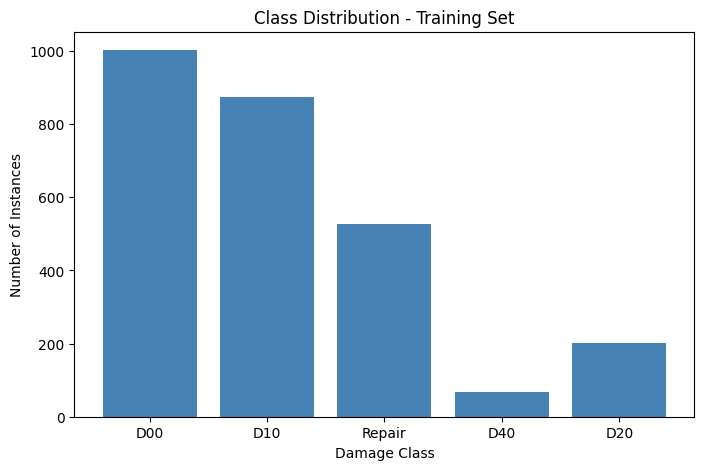

In [3]:
import os
import yaml
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

DATASET_DIR = dataset.location  # من الخطوة اللي فاتت

# --- 1. قراءة data.yaml ---
with open(f"{DATASET_DIR}/data.yaml") as f:
    data_config = yaml.safe_load(f)

class_names = data_config['names']
print("Classes:", class_names)

# --- 2. عدد الصور في كل split ---
splits = ['train', 'valid', 'test']
counts = {}
for split in splits:
    img_dir = f"{DATASET_DIR}/{split}/images"
    counts[split] = len(os.listdir(img_dir))

print("\nImage counts per split:")
for split, count in counts.items():
    print(f"  {split}: {count}")

# --- 3. توزيع الكلاسات في كل split ---
def get_class_distribution(split):
    label_dir = f"{DATASET_DIR}/{split}/labels"
    class_counter = Counter()
    for label_file in os.listdir(label_dir):
        with open(f"{label_dir}/{label_file}") as f:
            for line in f:
                class_id = int(line.split()[0])
                class_counter[class_names[class_id]] += 1
    return class_counter

print("\nClass distribution:")
all_distributions = {}
for split in splits:
    dist = get_class_distribution(split)
    all_distributions[split] = dist
    print(f"\n  {split}:")
    for cls, cnt in sorted(dist.items(), key=lambda x: -x[1]):
        print(f"    {cls}: {cnt}")

# --- 4. رسم بياني لتوزيع الكلاسات (train) ---
train_dist = all_distributions['train']
plt.figure(figsize=(8, 5))
plt.bar(train_dist.keys(), train_dist.values(), color='steelblue')
plt.title("Class Distribution - Training Set")
plt.ylabel("Number of Instances")
plt.xlabel("Damage Class")
plt.show()

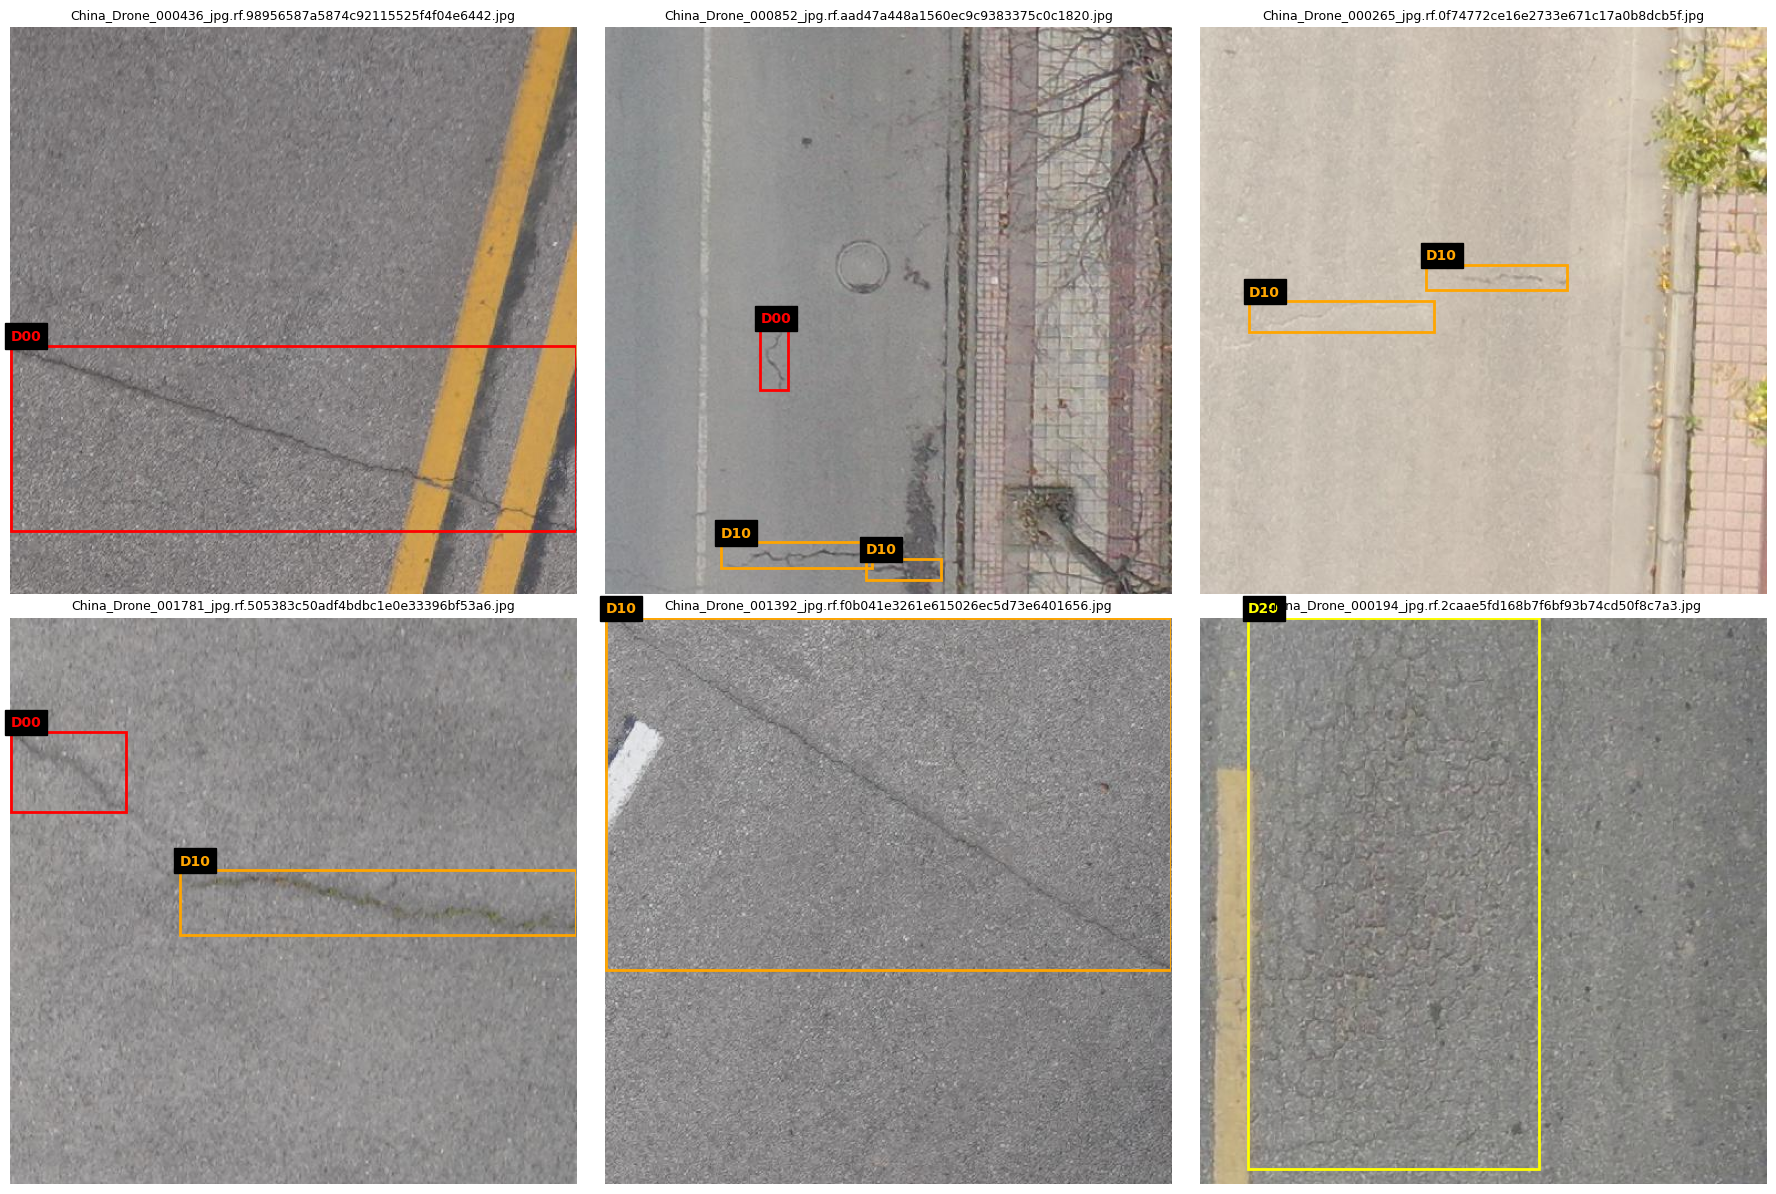

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random
import os

colors = {'D00': 'red', 'D10': 'orange', 'D20': 'yellow', 'D40': 'lime', 'Repair': 'cyan'}

def visualize_sample(split='train', n=6):
    img_dir = f"{DATASET_DIR}/{split}/images"
    label_dir = f"{DATASET_DIR}/{split}/labels"

    img_files = random.sample(os.listdir(img_dir), n)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for idx, img_file in enumerate(img_files):
        img_path = f"{img_dir}/{img_file}"
        label_path = f"{label_dir}/{os.path.splitext(img_file)[0]}.txt"

        img = Image.open(img_path)
        w, h = img.size

        ax = axes[idx]
        ax.imshow(img)

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.split()
                    cls_id = int(parts[0])
                    x_center, y_center, box_w, box_h = map(float, parts[1:5])

                    # تحويل من YOLO format (normalized) لبكسلات
                    x_center *= w
                    y_center *= h
                    box_w *= w
                    box_h *= h

                    x_min = x_center - box_w / 2
                    y_min = y_center - box_h / 2

                    cls_name = class_names[cls_id]
                    rect = patches.Rectangle(
                        (x_min, y_min), box_w, box_h,
                        linewidth=2, edgecolor=colors.get(cls_name, 'red'), facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(x_min, y_min - 5, cls_name, color=colors.get(cls_name, 'red'),
                            fontsize=10, fontweight='bold', backgroundcolor='black')

        ax.set_title(img_file, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

visualize_sample('train', n=6)

In [5]:
!pip install ultralytics -q

import ultralytics
ultralytics.checks()

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.0/112.6 GB disk)


In [6]:
from ultralytics import YOLO

model_v11 = YOLO('yolo11s.pt')

results_v11 = model_v11.train(
    data=f"{DATASET_DIR}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    project='road_damage_detection',
    name='yolo11s',
    seed=42,
    exist_ok=True
)

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RDD2022_China_Drone-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s, nbs=64, nms=

In [ ]:
from ultralytics import YOLO

model_v8 = YOLO('yolov8s.pt')

results_v8 = model_v8.train(
    data=f"{DATASET_DIR}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    project='road_damage_detection',
    name='yolov8s',
    seed=42,
    exist_ok=True
)

Ultralytics 8.4.110 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RDD2022_China_Drone-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s, nbs=64, nms=

In [ ]:
from ultralytics import YOLO

model_v9 = YOLO('yolov9s.pt')

results_v9 = model_v9.train(
    data=f"{DATASET_DIR}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    project='road_damage_detection',
    name='yolov9s',
    seed=42,
    exist_ok=True
)

Ultralytics 8.4.110 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RDD2022_China_Drone-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9s, nbs=64, nms=

In [ ]:
import shutil

shutil.make_archive('training_results_backup', 'zip', '/content/runs/detect/road_damage_detection')

from google.colab import files
files.download('training_results_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
from google.colab import files
uploaded = files.upload()

Saving training_results_backup.zip to training_results_backup.zip


In [10]:
import zipfile
import shutil
import os

# فك الضغط في فولدر مؤقت
os.makedirs('/content/temp_extract', exist_ok=True)
with zipfile.ZipFile('/content/training_results_backup.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/temp_extract')

# انقل بس yolov8s و yolov9s للمكان الصحيح (من غير ما نمسح yolo11s)
target_base = '/content/runs/detect/road_damage_detection'
os.makedirs(target_base, exist_ok=True)

for model_name in ['yolov8s', 'yolov9s']:
    src = f'/content/temp_extract/{model_name}'
    dst = f'{target_base}/{model_name}'
    if os.path.exists(src):
        if os.path.exists(dst):
            shutil.rmtree(dst)  # لو موجود فولدر فاضي أو قديم، نمسحه الأول
        shutil.move(src, dst)
        print(f"✅ اتنقل: {model_name}")
    else:
        print(f"⚠️ مش موجود في الـ zip: {model_name}")

# تنضيف الفولدر المؤقت
shutil.rmtree('/content/temp_extract')

✅ اتنقل: yolov8s
✅ اتنقل: yolov9s


In [11]:
!find /content/runs/detect/road_damage_detection -maxdepth 1 -type d
!find /content/runs/detect/road_damage_detection -name "results.csv"

/content/runs/detect/road_damage_detection
/content/runs/detect/road_damage_detection/yolov8s
/content/runs/detect/road_damage_detection/yolov9s
/content/runs/detect/road_damage_detection/yolo11s
/content/runs/detect/road_damage_detection/yolov8s/results.csv
/content/runs/detect/road_damage_detection/yolov9s/results.csv
/content/runs/detect/road_damage_detection/yolo11s/results.csv


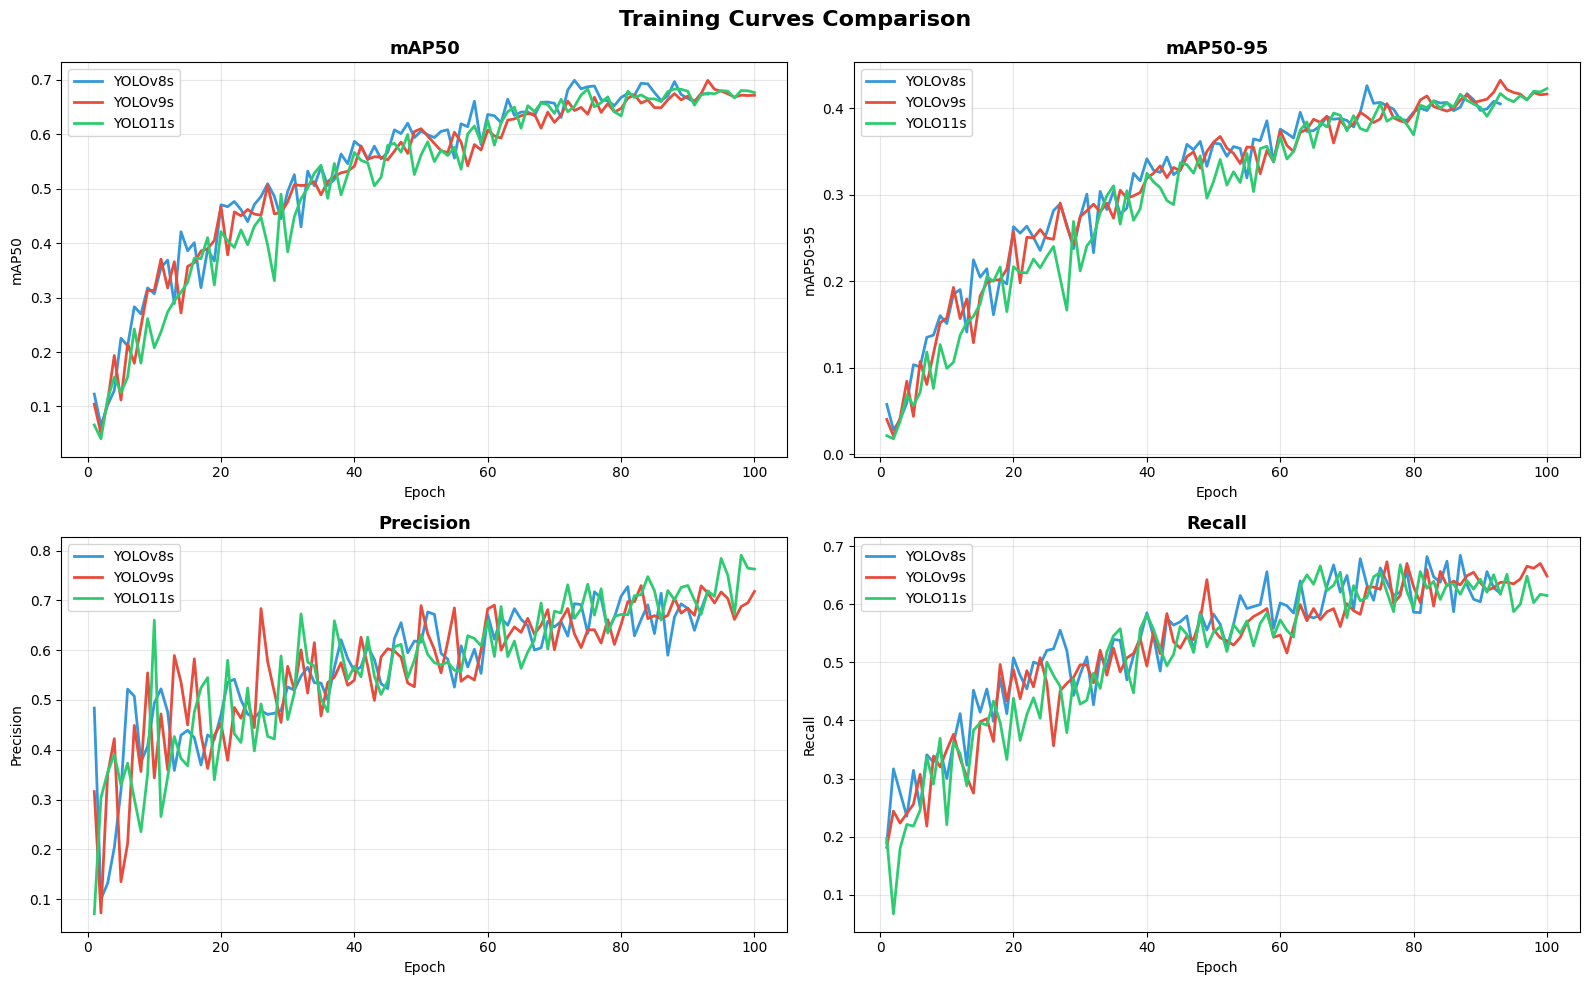

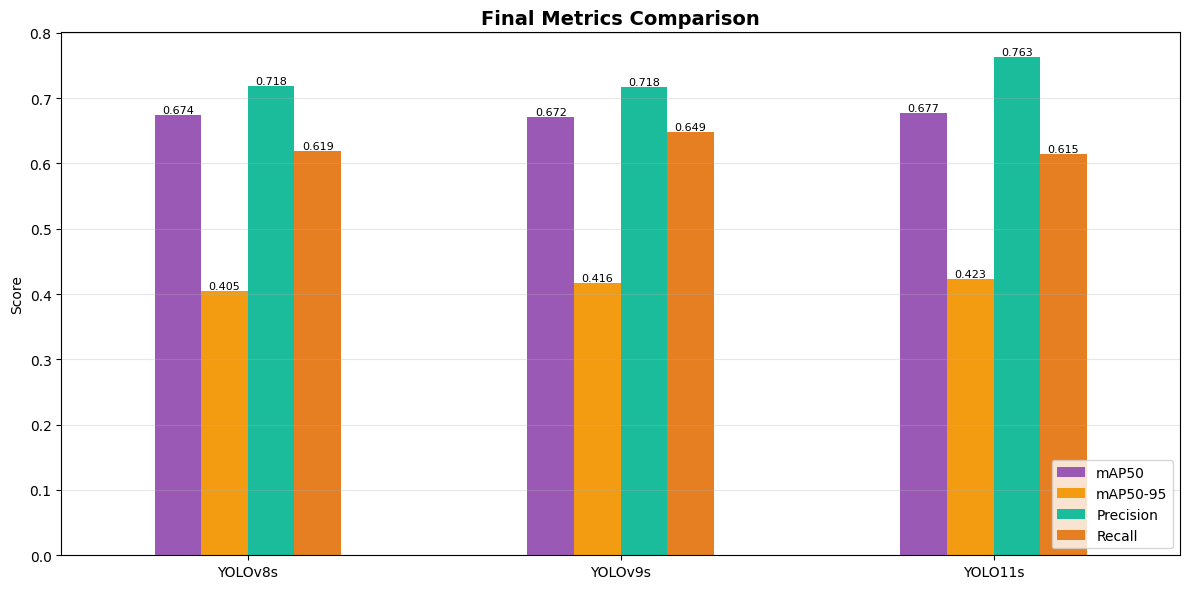

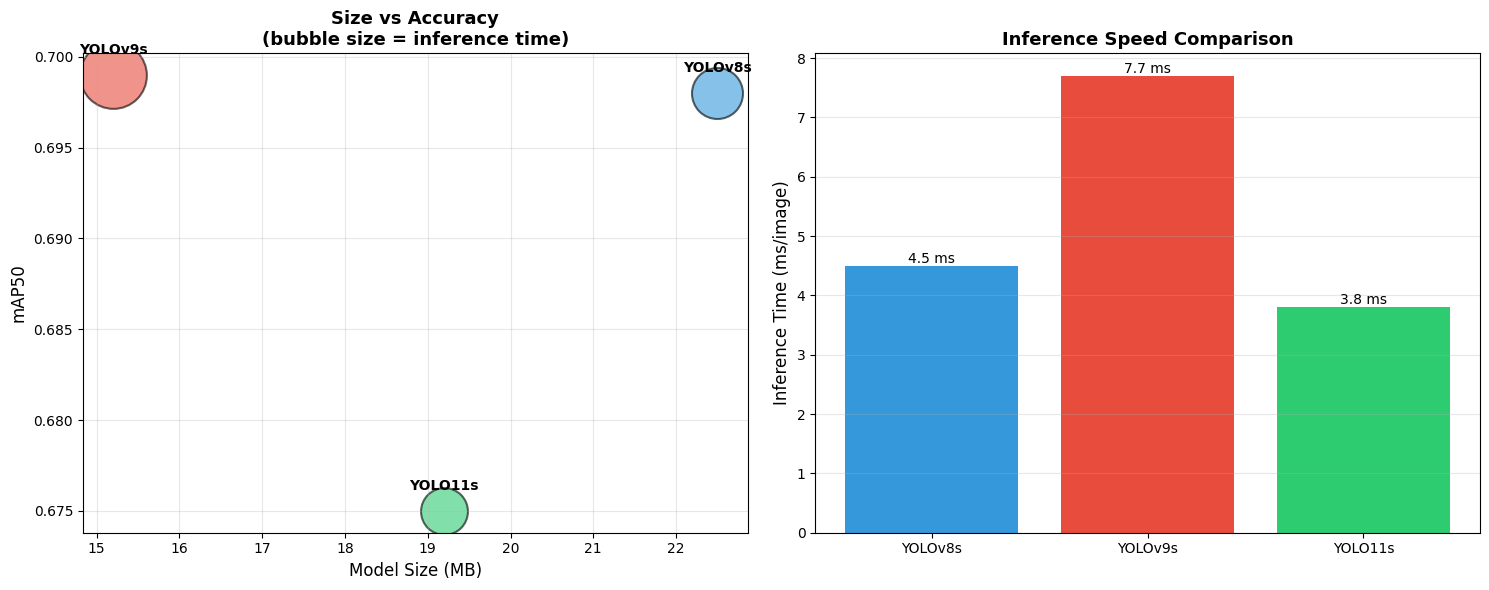

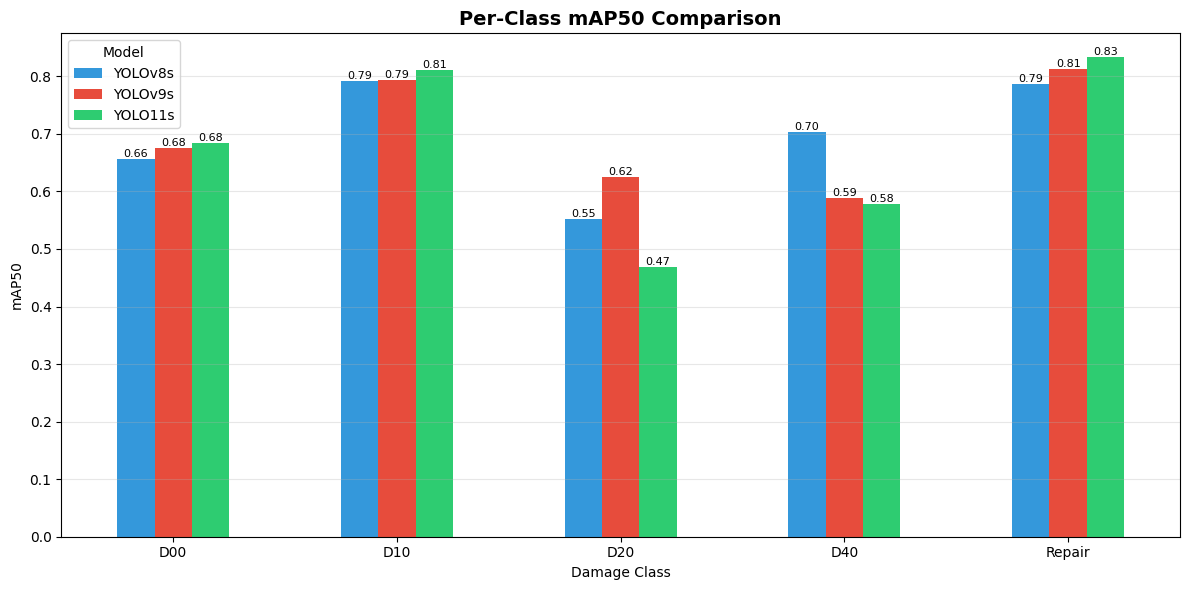

✅ كل الرسومات اتحفظت


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- تحميل results.csv بتاع كل موديل ---
base_path = "/content/runs/detect/road_damage_detection"

models = {
    'YOLOv8s': f'{base_path}/yolov8s/results.csv',
    'YOLOv9s': f'{base_path}/yolov9s/results.csv',
    'YOLO11s': f'{base_path}/yolo11s/results.csv'
}

colors = {'YOLOv8s': '#3498db', 'YOLOv9s': '#e74c3c', 'YOLO11s': '#2ecc71'}

data = {}
for name, path in models.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    data[name] = df

# --- Figure 1: منحنيات التدريب عبر الـ epochs ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_to_plot = [
    ('metrics/mAP50(B)', 'mAP50'),
    ('metrics/mAP50-95(B)', 'mAP50-95'),
    ('metrics/precision(B)', 'Precision'),
    ('metrics/recall(B)', 'Recall')
]

for idx, (col, title) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    for name, df in data.items():
        ax.plot(df['epoch'], df[col], label=name, color=colors[name], linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training Curves Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 2: مقارنة الأداء النهائي (Bar Chart) ---
final_metrics = {}
for name, df in data.items():
    last_row = df.iloc[-1]
    final_metrics[name] = {
        'mAP50': last_row['metrics/mAP50(B)'],
        'mAP50-95': last_row['metrics/mAP50-95(B)'],
        'Precision': last_row['metrics/precision(B)'],
        'Recall': last_row['metrics/recall(B)']
    }

metrics_df = pd.DataFrame(final_metrics).T

fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, color=['#9b59b6', '#f39c12', '#1abc9c', '#e67e22'])
ax.set_title('Final Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(metrics_df.index, rotation=0)
ax.legend(loc='lower right')
ax.grid(alpha=0.3, axis='y')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.savefig('comparison_final_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 3: Efficiency Trade-off (Speed vs Size vs Accuracy) ---
model_info = {
    'YOLOv8s': {'params_M': 11.1, 'size_MB': 22.5, 'inference_ms': 4.5, 'mAP50': 0.698},
    'YOLOv9s': {'params_M': 7.3,  'size_MB': 15.2, 'inference_ms': 7.7, 'mAP50': 0.699},
    'YOLO11s': {'params_M': 9.4,  'size_MB': 19.2, 'inference_ms': 3.8, 'mAP50': 0.675},
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
for name, info in model_info.items():
    ax1.scatter(info['size_MB'], info['mAP50'], s=info['inference_ms']*300,
                color=colors[name], alpha=0.6, edgecolors='black', linewidth=1.5, label=name)
    ax1.annotate(name, (info['size_MB'], info['mAP50']),
                 textcoords="offset points", xytext=(0, 15), ha='center', fontweight='bold')
ax1.set_xlabel('Model Size (MB)', fontsize=12)
ax1.set_ylabel('mAP50', fontsize=12)
ax1.set_title('Size vs Accuracy\n(bubble size = inference time)', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

ax2 = axes[1]
names = list(model_info.keys())
speeds = [model_info[n]['inference_ms'] for n in names]
bars = ax2.bar(names, speeds, color=[colors[n] for n in names])
ax2.set_ylabel('Inference Time (ms/image)', fontsize=12)
ax2.set_title('Inference Speed Comparison', fontsize=13, fontweight='bold')
ax2.bar_label(bars, fmt='%.1f ms')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('comparison_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 4: مقارنة الأداء لكل كلاس ---
per_class_data = {
    'D00':    {'YOLOv8s': 0.656, 'YOLOv9s': 0.676, 'YOLO11s': 0.684},
    'D10':    {'YOLOv8s': 0.792, 'YOLOv9s': 0.794, 'YOLO11s': 0.811},
    'D20':    {'YOLOv8s': 0.552, 'YOLOv9s': 0.625, 'YOLO11s': 0.468},
    'D40':    {'YOLOv8s': 0.703, 'YOLOv9s': 0.588, 'YOLO11s': 0.578},
    'Repair': {'YOLOv8s': 0.787, 'YOLOv9s': 0.812, 'YOLO11s': 0.833},
}

per_class_df = pd.DataFrame(per_class_data).T

fig, ax = plt.subplots(figsize=(12, 6))
per_class_df.plot(kind='bar', ax=ax, color=[colors['YOLOv8s'], colors['YOLOv9s'], colors['YOLO11s']])
ax.set_title('Per-Class mAP50 Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('mAP50')
ax.set_xlabel('Damage Class')
ax.set_xticklabels(per_class_df.index, rotation=0)
ax.legend(title='Model')
ax.grid(alpha=0.3, axis='y')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8)

plt.tight_layout()
plt.savefig('comparison_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ كل الرسومات اتحفظت")

In [13]:
!pip install gradio -q

In [ ]:
import gradio as gr
from ultralytics import YOLO
from PIL import Image
import numpy as np

# --- تحميل أفضل موديل (YOLO11s) ---
MODEL_PATH = "/content/runs/detect/road_damage_detection/yolo11s/weights/best.pt"
model = YOLO(MODEL_PATH)

# ألوان مخصصة لكل كلاس (اختياري، بس بيدي شكل احترافي)
class_colors = {
    'D00': (255, 0, 0),      # أحمر - شرخ طولي
    'D10': (255, 165, 0),    # برتقالي - شرخ عرضي
    'D20': (255, 255, 0),    # أصفر - تمساحي
    'D40': (255, 0, 255),    # بنفسجي - حفرة
    'Repair': (0, 255, 255), # سماوي - منطقة مُصلَّحة
}

def detect_road_damage(image, confidence_threshold):
    """
    تشغل الموديل على الصورة المرفوعة وترجع الصورة مع الـ boxes + جدول تفصيلي
    """
    if image is None:
        return None, "من فضلك ارفع صورة أولاً."

    # تشغيل الاستدلال (inference)
    results = model.predict(
        source=image,
        conf=confidence_threshold,
        imgsz=640,
        verbose=False
    )

    result = results[0]

    # رسم الـ boxes على الصورة (بيرجع numpy array بصيغة BGR، نحولها لـ RGB)
    annotated_frame = result.plot()
    annotated_image = Image.fromarray(annotated_frame[..., ::-1])

    # بناء تقرير نصي بالتفاصيل
    boxes = result.boxes
    if len(boxes) == 0:
        summary = "✅ لم يتم اكتشاف أي أضرار في الصورة (بناءً على حد الثقة المحدد)."
    else:
        class_counts = {}
        details = []
        for box in boxes:
            cls_id = int(box.cls[0])
            cls_name = model.names[cls_id]
            conf = float(box.conf[0])
            class_counts[cls_name] = class_counts.get(cls_name, 0) + 1
            details.append(f"  • {cls_name} — ثقة: {conf:.1%}")

        summary = f"🔍 تم اكتشاف {len(boxes)} حالة ضرر:\n\n"
        summary += "\n".join(f"- {cls}: {count}" for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]))
        summary += "\n\nالتفاصيل:\n" + "\n".join(details)

    return annotated_image, summary


# --- بناء الواجهة ---
with gr.Blocks(title="Road Damage Detection", theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # 🛣️ Road Damage Object Detection
        ### كشف أضرار الطرق باستخدام YOLO11s
        ارفع صورة جوية (Drone) للطريق، وسيقوم النظام باكتشاف أنواع الأضرار:
        **D00** (شرخ طولي) • **D10** (شرخ عرضي) • **D20** (تشققات تمساحية) • **D40** (حفر) • **Repair** (مناطق مُصلَّحة)
        """
    )

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type="pil", label="ارفع صورة الطريق")
            confidence_slider = gr.Slider(
                minimum=0.1, maximum=0.9, value=0.25, step=0.05,
                label="حد الثقة (Confidence Threshold)"
            )
            detect_btn = gr.Button("🔍 كشف الأضرار", variant="primary")

        with gr.Column():
            output_image = gr.Image(type="pil", label="النتيجة")
            output_text = gr.Textbox(label="التقرير التفصيلي", lines=10)

    detect_btn.click(
        fn=detect_road_damage,
        inputs=[input_image, confidence_slider],
        outputs=[output_image, output_text]
    )

    gr.Markdown(
        """
        ---
        **الموديل**: YOLO11s | **الداتاست**: RDD2022 - China Drone Subset (2,393 صورة)
        """
    )

demo.launch(share=True, debug=True)

The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3ba9a26afe5b97bf37.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
